In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Load CSV
df = pd.read_csv("AQPX_data_log_2025-12-16.csv")

In [3]:
df["Time"] = df["Time"].astype(str)
df["Time"] = df["Time"].str.strip()
dtime = pd.to_datetime("2025-11-30 " + df["Time"], errors="coerce")
dtime_orig = dtime

In [4]:
do = df["MCP_WQ_DO"]

In [5]:
#downscale values
factor = 20
dtime_small = dtime[::factor]
do_small = do[::factor]

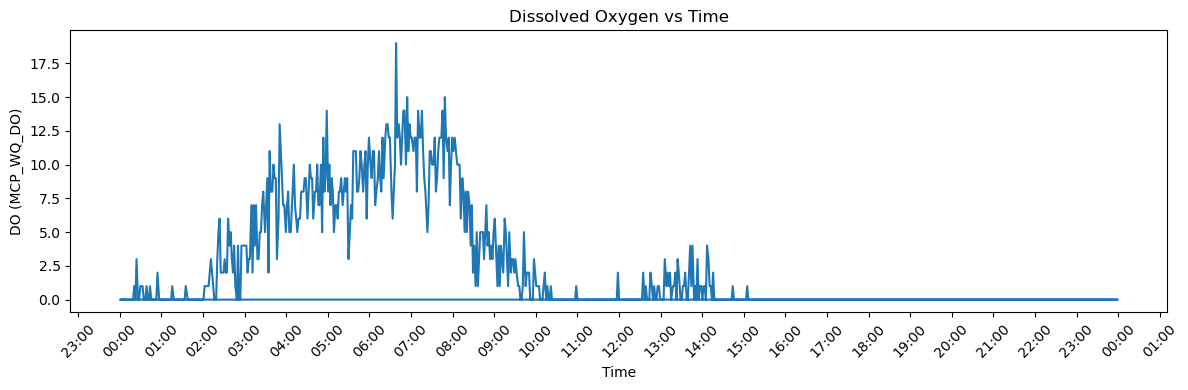

In [6]:
plt.figure(figsize=(12,4))
plt.plot(dtime_small, do_small)

plt.xlabel("Time")
plt.ylabel("DO (MCP_WQ_DO)")
plt.title("Dissolved Oxygen vs Time")

# HOURLY TICKS
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Notes:
1. Early morning: DO is high as water is cooler and fish activity is low.
2. Mid-morning: DO peaks as hydroponics set-up produces DO and water is still cool
3. Noon to afternoon: DO drops as fish activity increases
4. Evening: DO increases again as fish activity decreases and water cools
5. Given that the pattern is extremely natural, it is likely that there is no running aerator.
6. What we are seeing is the pure environmental response.
7. QUESTION: Are they actually using the aerator now? If so, when do they activate it?

Files found: ['C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-01.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-02.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-03.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-04.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-05.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-06.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-07.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-08.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-09.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-10.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-12.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-15.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-16.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2025-12-17.csv']
Loading: C:\Users\Dindo\Documents\aqpx\AQPX_data

KeyError: 'Time'

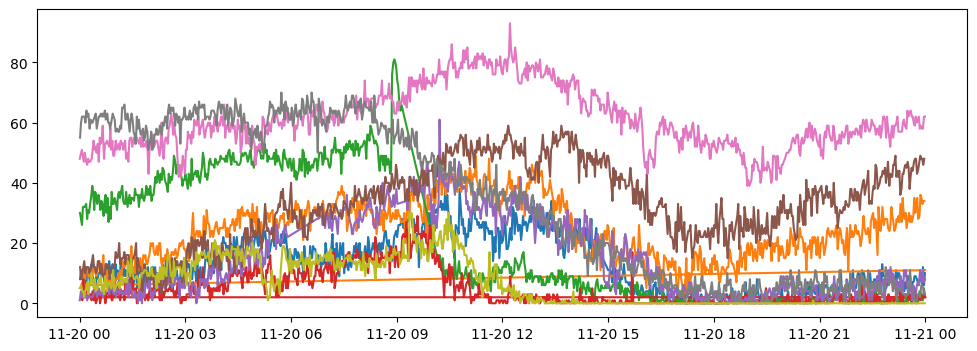

In [7]:
import glob

# ---- SETTINGS ----
folder = "C:\\Users\\Dindo\\Documents\\aqpx"
downsample_factor = 20

# ---- FIND ALL CSV FILES ----
csv_files = glob.glob(f"{folder}/*.csv")

print("Files found:", csv_files)

plt.figure(figsize=(12, 4))

# ---- PROCESS EACH FILE ----
for file in csv_files:
    print("Loading:", file)

    df = pd.read_csv(file)

    # Convert Time column
    df["Time"] = df["Time"].astype(str).str.strip()
    dtime = pd.to_datetime("2025-11-20 " + df["Time"], errors="coerce")

    # Get DO values
    do = df["MCP_WQ_DO"]

    # Downsample (optional)
    dtime_small = dtime[::downsample_factor]
    do_small = do[::downsample_factor]

    # Plot each CSV
    plt.plot(dtime_small, do_small, label=file.split("\\")[-1])

# ---- GRAPH SETTINGS ----
plt.xlabel("Time")
plt.ylabel("DO (MCP_WQ_DO)")
plt.title("Dissolved Oxygen vs Time (Multiple Days)")

plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import glob
import re

# -----------------------------
# 1. FOLDER WITH YOUR CSV FILES
# -----------------------------
folder = r"C:\Users\Dindo\Documents\aqpx"

# Find all CSV files
csv_files = glob.glob(f"{folder}/*.csv")

print("Files found:")
for f in csv_files:
    print(" -", f)

# A list to store each day's DataFrame
frames = []

# -----------------------------
# 2. PROCESS EACH CSV
# -----------------------------
for file in csv_files:

    # Extract date from filename (YYYY-MM-DD)
    match = re.search(r"(\d{4}-\d{2}-\d{2})", file)
    if match:
        date_str = match.group(1)
    else:
        raise ValueError(f"ERROR: No date found in filename: {file}")

    print(f"Loading {file} (date: {date_str})")

    # Load CSV
    df = pd.read_csv(file)

    # Fix Time column
    df["Time"] = df["Time"].astype(str).str.strip()

    # Combine date + time
    df["DateTime"] = pd.to_datetime(date_str + " " + df["Time"], errors="coerce")

    frames.append(df)

# -----------------------------
# 3. STITCH ALL CSVs TOGETHER
# -----------------------------
full_df = pd.concat(frames, ignore_index=True)

# Sort chronologically (important!)
full_df = full_df.sort_values("DateTime").reset_index(drop=True)

print("\nStitched dataframe preview:")
print(full_df.head())
print(full_df.tail())

# downscale
factor = 20
dtime = full_df["DateTime"]
do = full_df["MCP_WQ_DO"]

dtime_small = dtime[::factor]
do_small = do[::factor]

plt.figure(figsize=(14, 5))
plt.plot(dtime_small, do_small, linewidth=1)

plt.title("Dissolved Oxygen vs Time (Multiple Days)")
plt.xlabel("DateTime")
plt.ylabel("DO (MCP_WQ_DO)")

# Major time ticks every 6 hours
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Load CSV
df = pd.read_csv("AQPX_data_log_2025-11-30.csv")

dtds = df["MCP_WQ_TDS"]
dtime = pd.to_datetime("2025-11-30 " + df["Time"], errors="coerce")
dtime_orig = dtime

In [ ]:
#downscale values
factor = 20
dtime_small = dtime[::factor]
dtds_small = dtds[::factor]

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(dtime_small, dtds_small)

plt.xlabel("Time")
plt.ylabel("Total Dissolved Solids (MCP_WQ_TDS)")
plt.title("Total Dissolved Solids vs Time")

# HOURLY TICKS
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


1. TDS falls in the early monitoring as plants absorb nutrients
2. TDS increases from morning to afternoon as plant intake decreases and fish activity / feeding / waste generation increases
3. If you look at the y-axis / TDS values though, they vary between 196 and 210 only - this indicates that TDS does not change significantly.
4. QUESTION: Are they actually running the pump at this point? And at what intervals?

In [ ]:
import glob

# ---- SETTINGS ----
folder = "C:\\Users\\Dindo\\Documents\\aqpx"
downsample_factor = 20

# ---- FIND ALL CSV FILES ----
csv_files = glob.glob(f"{folder}/*.csv")

print("Files found:", csv_files)

plt.figure(figsize=(12, 4))

# ---- PROCESS EACH FILE ----
for file in csv_files:
    print("Loading:", file)

    df = pd.read_csv(file)

    # Convert Time column
    df["Time"] = df["Time"].astype(str).str.strip()
    dtime = pd.to_datetime("2025-11-20 " + df["Time"], errors="coerce")

    # Get DO values
    dtds = df["MCP_WQ_TDS"]

    # Downsample (optional)
    dtime_small = dtime[::downsample_factor]
    dtds_small = dtds[::downsample_factor]

    # Plot each CSV
    plt.plot(dtime_small, dtds_small, label=file.split("\\")[-1])

# ---- GRAPH SETTINGS ----
plt.xlabel("Time")
plt.ylabel("Total Dissolved Solids (MCP_WQ_TDS)")
plt.title("Total Dissolved Solids vs Time (Multiple CSVs)")

plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import glob
import re

# -----------------------------
# 1. FOLDER WITH YOUR CSV FILES
# -----------------------------
folder = r"C:\Users\Dindo\Documents\aqpx"

# Find all CSV files
csv_files = glob.glob(f"{folder}/*.csv")

print("Files found:")
for f in csv_files:
    print(" -", f)

# A list to store each day's DataFrame
frames = []

# -----------------------------
# 2. PROCESS EACH CSV
# -----------------------------
for file in csv_files:

    # Extract date from filename (YYYY-MM-DD)
    match = re.search(r"(\d{4}-\d{2}-\d{2})", file)
    if match:
        date_str = match.group(1)
    else:
        raise ValueError(f"ERROR: No date found in filename: {file}")

    print(f"Loading {file} (date: {date_str})")

    # Load CSV
    df = pd.read_csv(file)

    # Fix Time column
    df["Time"] = df["Time"].astype(str).str.strip()

    # Combine date + time
    df["DateTime"] = pd.to_datetime(date_str + " " + df["Time"], errors="coerce")

    frames.append(df)

# -----------------------------
# 3. STITCH ALL CSVs TOGETHER
# -----------------------------
full_df = pd.concat(frames, ignore_index=True)

# Sort chronologically (important!)
full_df = full_df.sort_values("DateTime").reset_index(drop=True)

print("\nStitched dataframe preview:")
print(full_df.head())
print(full_df.tail())

# downscale
factor = 20
dtime = full_df["DateTime"]
dtds = full_df["MCP_WQ_TDS"]

dtime_small = dtime[::factor]
dtds_small = dtds[::factor]

plt.figure(figsize=(14, 5))
plt.plot(dtime_small, dtds_small, linewidth=1)

plt.title("Total Dissolved Solids vs Time (Multiple Days)")
plt.xlabel("DateTime")
plt.ylabel("Total Dissolved Solids (MCP_WQ_TDS)")

# Major time ticks every 6 hours
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
